### Setup RAG Pipeline Libraries
Installs essential libraries (`langchain`, `transformers`, `torch`, etc.) quietly for a RAG pipeline in Google Colab. Imports required modules for document processing, embeddings, vector stores, and LLMs. Configures logging for visibility and optionally enables in-memory caching for query optimization. Verifies setup with a confirmation message.

In [1]:
# Install required libraries
!pip install -q langchain langchain-community sentence-transformers transformers torch bitsandbytes accelerate faiss-cpu gradio pandas

# Import libraries for RAG pipeline
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain.globals import set_llm_cache
from langchain.cache import InMemoryCache
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
import logging
import sys
from google.colab import userdata, files
import pandas as pd

# Configure logging for Colab visibility
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logging.getLogger().setLevel(logging.INFO)

# Enable caching for repeated queries
# set_llm_cache(InMemoryCache())

# Verify installation
print("Libraries installed and imported successfully.")
logging.info("Libraries installed and imported successfully.")

INFO:root:Libraries installed and imported successfully.


Libraries installed and imported successfully.


### Verify T4 GPU Availability
Checks for T4 GPU availability in Colab using `torch.cuda.is_available()`. Logs and prints the device (`cuda` or `cpu`). If a GPU is detected, displays its name (e.g., "Tesla T4") and warns if it’s not a T4. If no GPU is found, suggests switching to a T4 GPU in runtime settings.

In [2]:
# Check if T4 GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")
logging.info(f"Running on device: {device}")

# Display GPU details if available
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU Name: {gpu_name}")
    logging.info(f"GPU Name: {gpu_name}")
    if "T4" not in gpu_name:
        print("Warning: T4 GPU not detected; ensure T4 is selected in Runtime > Change runtime type.")
else:
    print("No GPU detected; running on CPU. Switch to T4 GPU in Runtime > Change runtime type.")
    logging.warning("No GPU detected; running on CPU.")

INFO:root:Running on device: cuda
INFO:root:GPU Name: Tesla T4


Running on device: cuda
GPU Name: Tesla T4


### Load and Process Travel Data
Uploads a CSV file in Colab using `files.upload()` and loads it into a Pandas DataFrame with 'latin1' encoding. Logs and prints the number of entries (e.g., 1024). Converts each row into a detailed text string with travel details (destination, country, costs, etc.) for RAG processing, logging and printing the conversion. Includes visualizations: bar plots (destinations per country, costs), box plots (transport costs), scatter plot (distance vs. cost), pie chart (destination types), heatmap (correlations), and average total cost by country.

INFO:root:Loaded 1024 travel data entries from CSV.
INFO:root:Converted 1024 CSV rows into text entries.


Saving Travel_Planner.csv to Travel_Planner (4).csv
Uploaded file: Travel_Planner (4).csv
Loaded 1024 travel data entries from CSV.
Converted 1024 CSV rows into text entries.


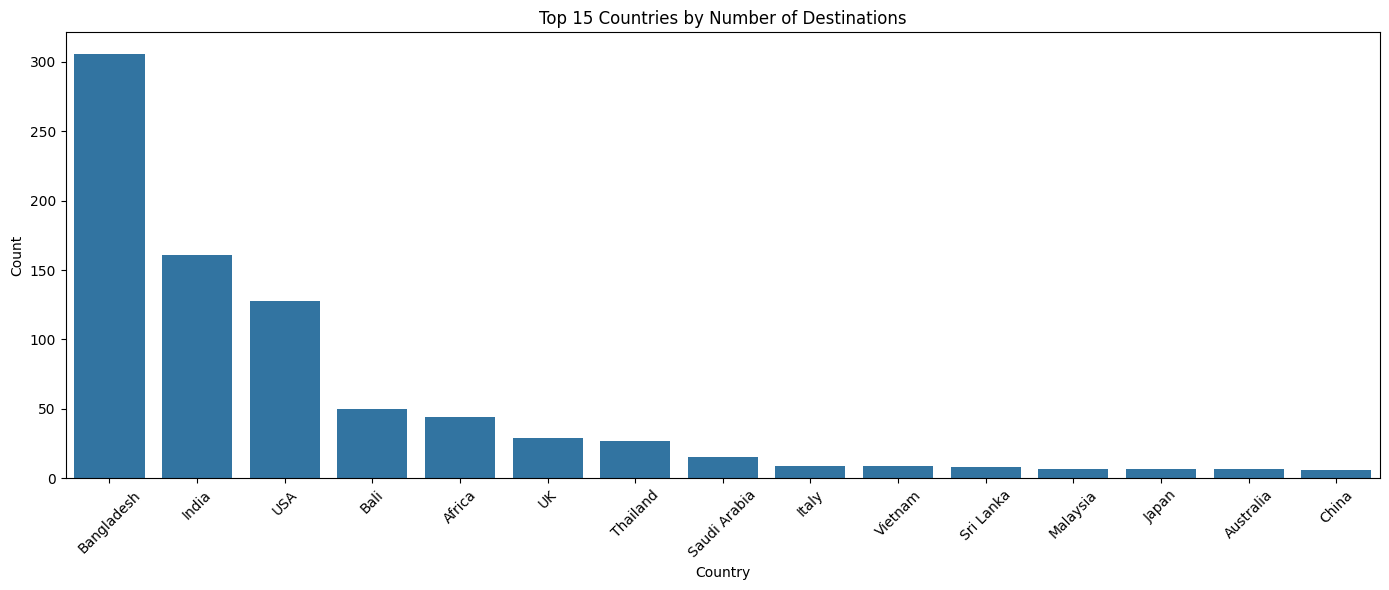

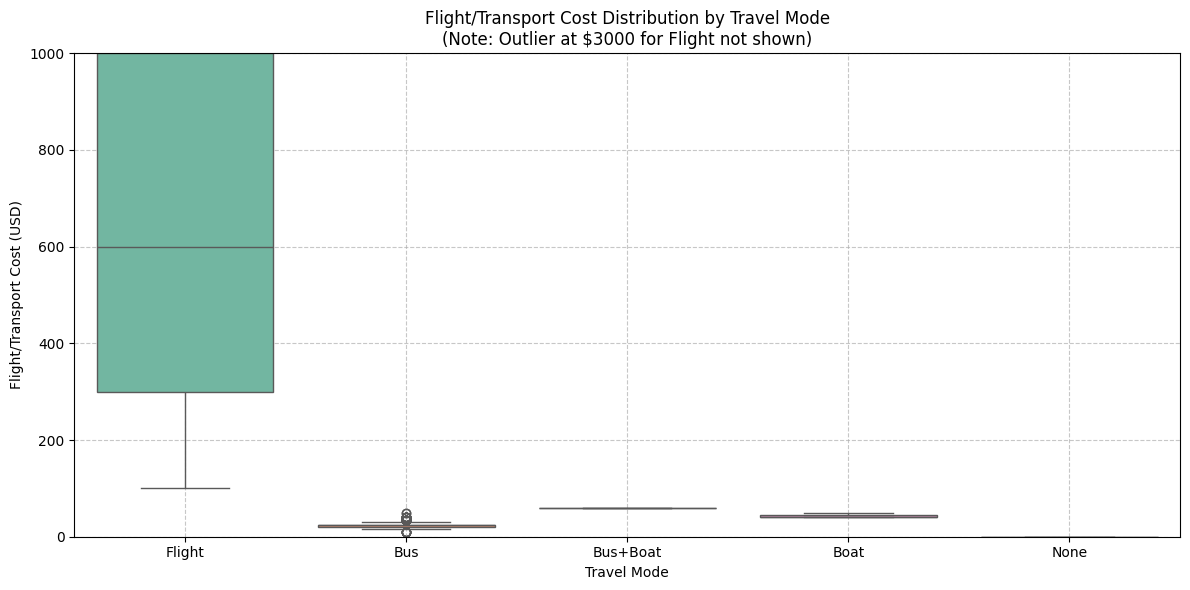

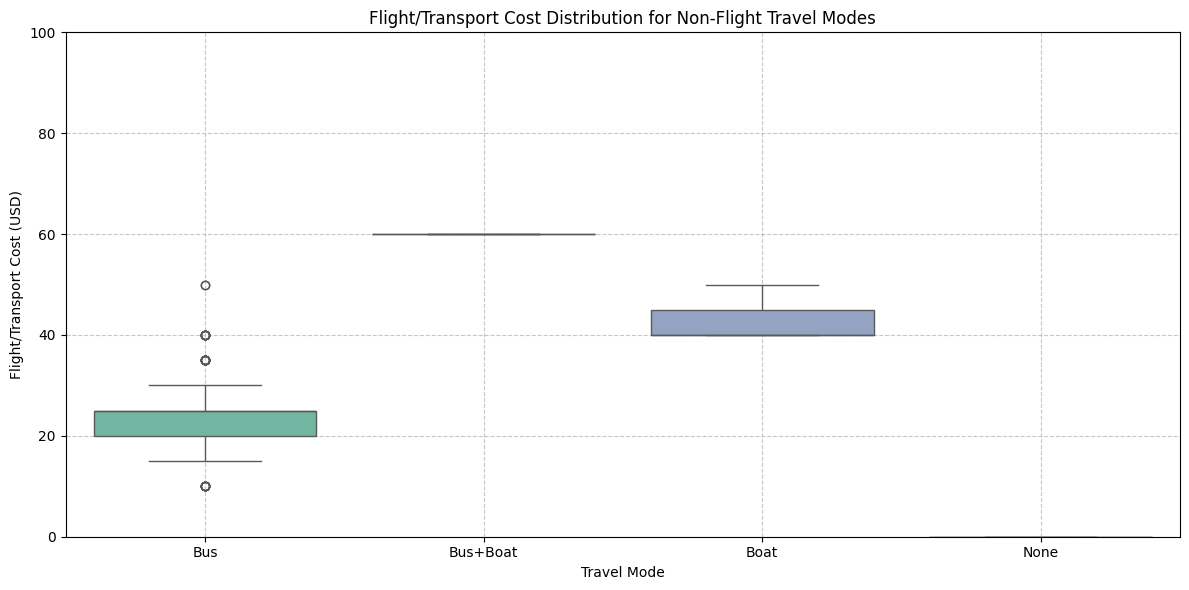

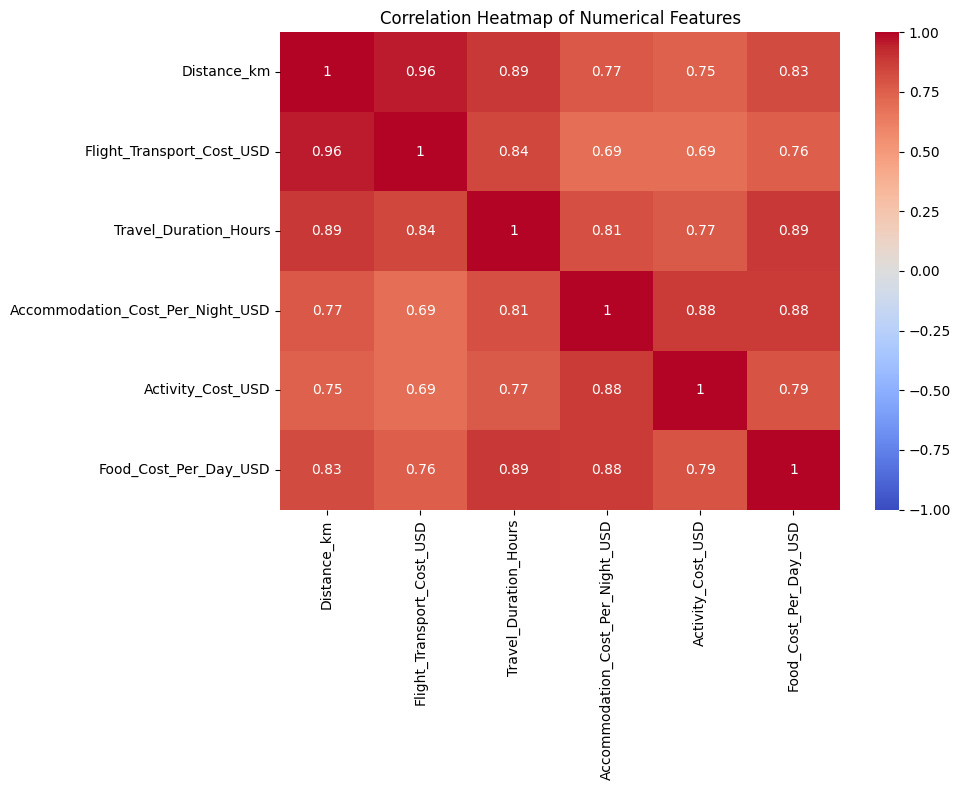

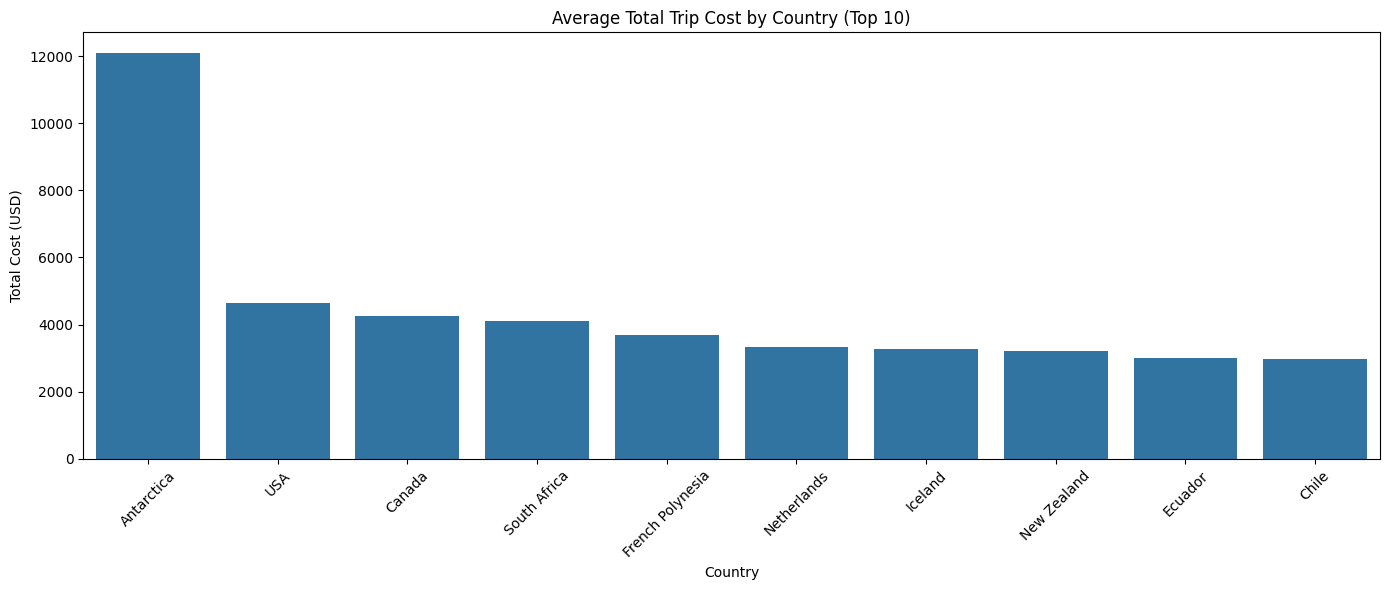

In [3]:
!pip install -q seaborn plotly
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Upload CSV file in Colab
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]  # Get the uploaded file name
print(f"Uploaded file: {csv_file}")

# Load CSV into DataFrame
travel_df = pd.read_csv(csv_file, encoding='latin1')
print(f"Loaded {len(travel_df)} travel data entries from CSV.")
logging.info(f"Loaded {len(travel_df)} travel data entries from CSV.")

# Convert DataFrame rows into text strings for RAG
travel_data = []
for index, row in travel_df.iterrows():
    text = (
        f"Destination: {row['Destination_Name']}, Country: {row['Country']}, City: {row['City']}, "
        f"Type: {row['Destination_Type']}, Starting Point: {row['Starting_Point']}, Distance: {row['Distance_km']} km, "
        f"Travel Mode: {row['Travel_Mode']}, Flight/Transport Cost: ${row['Flight_Transport_Cost_USD']}, "
        f"Travel Duration: {row['Travel_Duration_Hours']} hours, Accommodation Options: {row['Accommodation_Options']}, "
        f"Accommodation Cost: ${row['Accommodation_Cost_Per_Night_USD']} per night, Recommended Stay: {row['Recommended_Stay_Days']} days, "
        f"Top Attractions: {row['Top_Attractions']}, Activity Cost: ${row['Activity_Cost_USD']}, "
        f"Activity Duration: {row['Activity_Duration_Hours']} hours, Food Options: {row['Food_Options']}, "
        f"Food Cost: ${row['Food_Cost_Per_Day_USD']} per day, Visa Required: {row['Visa_Required']}, "
        f"Visa Cost: ${row['Visa_Cost_USD']}, Miscellaneous Cost: ${row['Miscellaneous_Cost_USD']}, "
        f"Best Season: {row['Best_Season']}, Peak Season Cost Multiplier: {row['Peak_Season_Cost_Multiplier']}, "
        f"Local Currency: {row['Local_Currency']}, Exchange Rate to USD: {row['Exchange_Rate_to_USD']}"
    )
    travel_data.append(text)

print(f"Converted {len(travel_data)} CSV rows into text entries.")
logging.info(f"Converted {len(travel_data)} CSV rows into text entries.")


# --- Visualizations ---

# 1. Bar Plot: Number of Destinations per Country (Seaborn)
plt.figure(figsize=(14, 6))
sns.countplot(data=travel_df, x='Country', order=travel_df['Country'].value_counts().index[:15])  # Top 15 countries
plt.xticks(rotation=45)
plt.title('Top 15 Countries by Number of Destinations')
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2a. Box Plot: Flight/Transport Cost Distribution by Travel Mode (Linear Scale, All Modes)
plt.figure(figsize=(12, 6))
travel_df['Travel_Mode'] = travel_df['Travel_Mode'].fillna('None')  # Handle NaN values
sns.boxplot(data=travel_df, x='Travel_Mode', y='Flight_Transport_Cost_USD', hue='Travel_Mode', palette='Set2', legend=False)
plt.ylim(0, 1000)  # Cap y-axis to focus on majority of data (outlier at $3000 noted)
plt.grid(True, linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.title('Flight/Transport Cost Distribution by Travel Mode\n(Note: Outlier at $3000 for Flight not shown)')
plt.xlabel('Travel Mode')
plt.ylabel('Flight/Transport Cost (USD)')
plt.tight_layout()
plt.show()

# 2b. Box Plot: Flight/Transport Cost Distribution for Non-Flight Modes (Linear Scale)
plt.figure(figsize=(12, 6))
non_flight_df = travel_df[travel_df['Travel_Mode'] != 'Flight']  # Exclude Flight
sns.boxplot(data=non_flight_df, x='Travel_Mode', y='Flight_Transport_Cost_USD', hue='Travel_Mode', palette='Set2', legend=False)
plt.ylim(0, 100)  # Focus on smaller range for non-flight modes
plt.grid(True, linestyle='--', alpha=0.7)  # Add gridlines
plt.title('Flight/Transport Cost Distribution for Non-Flight Travel Modes')
plt.xlabel('Travel Mode')
plt.ylabel('Flight/Transport Cost (USD)')
plt.tight_layout()
plt.show()

# 3. Scatter Plot: Distance vs. Flight/Transport Cost (Plotly - Interactive)
fig = px.scatter(travel_df, x='Distance_km', y='Flight_Transport_Cost_USD', color='Destination_Type',
                 size='Travel_Duration_Hours', hover_data=['Destination_Name', 'Country'],
                 title='Distance vs. Flight/Transport Cost by Destination Type')
fig.update_layout(xaxis_title='Distance (km)', yaxis_title='Flight/Transport Cost (USD)')
fig.show()

# 4. Pie Chart: Proportion of Destination Types (Plotly - Interactive)
fig = px.pie(travel_df, names='Destination_Type', title='Proportion of Destination Types', hole=0.3)
fig.update_traces(textinfo='percent+label')
fig.show()

# 5. Heatmap: Correlation of Numerical Features (Seaborn)
plt.figure(figsize=(10, 8))
numerical_cols = ['Distance_km', 'Flight_Transport_Cost_USD', 'Travel_Duration_Hours',
                  'Accommodation_Cost_Per_Night_USD', 'Activity_Cost_USD', 'Food_Cost_Per_Day_USD']
corr = travel_df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

# 6. Bar Plot: Average Total Cost by Country (Seaborn)
travel_df['Total_Cost_USD'] = (travel_df['Flight_Transport_Cost_USD'] +
                               travel_df['Accommodation_Cost_Per_Night_USD'] * travel_df['Recommended_Stay_Days'] +
                               travel_df['Activity_Cost_USD'] +
                               travel_df['Food_Cost_Per_Day_USD'] * travel_df['Recommended_Stay_Days'] +
                               travel_df['Visa_Cost_USD'] +
                               travel_df['Miscellaneous_Cost_USD'])
plt.figure(figsize=(14, 6))
sns.barplot(data=travel_df, x='Country', y='Total_Cost_USD', estimator='mean', errorbar=None,
            order=travel_df.groupby('Country')['Total_Cost_USD'].mean().sort_values(ascending=False).index[:10])  # Top 10
plt.xticks(rotation=45)
plt.title('Average Total Trip Cost by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Total Cost (USD)')
plt.tight_layout()
plt.show()

### Prepare Documents
Defines `prepare_documents` to convert raw text into LangChain `Document` objects. Checks for missing values (None or empty strings), logs and prints the count (e.g., 0 out of 1024), and visualizes them with a Seaborn heatmap (saved as 'missing_values_heatmap.png'). Cleans data by stripping whitespace and replacing newlines. Extracts a key (e.g., destination after "Destination:") for deduplication, removes duplicates based on this key (keeping the first occurrence), and reports duplicate counts and deleted rows. Creates `Document` objects from unique entries, logs and prints the final count (e.g., reduced from 1024 if duplicates exist), and applies it to `travel_data`.

INFO:root:Found 0 missing or empty entries out of 1024 total entries.


Found 0 missing or empty entries out of 1024 total entries.


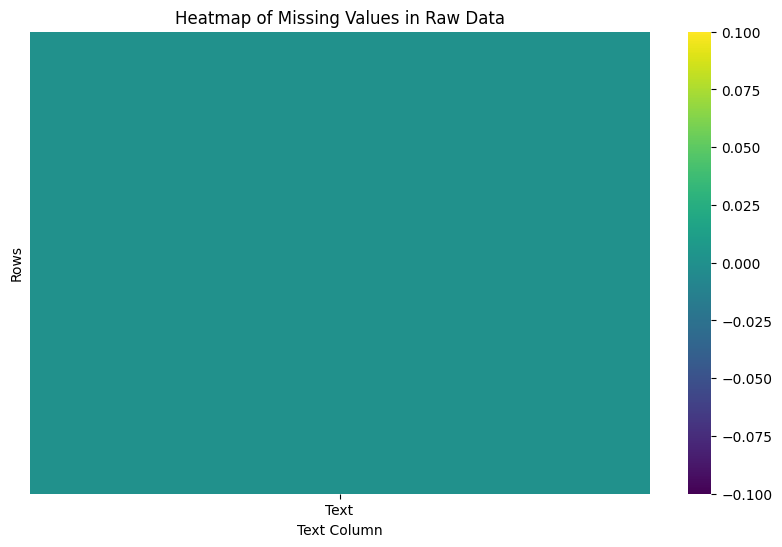

INFO:root:Prepared 999 Document objects after preprocessing.


Duplicate values found in column 'Key':
Key
Sanur           3
Goa             2
Chiang Mai      2
Florence        2
Doha            2
Muscat          2
Hampi           2
Udaipur         2
Madagascar      2
Gopalpur        2
Egypt           2
Morocco         2
South Africa    2
Estonia         2
San Marino      2
Tanzania        2
Chad            2
Kenya           2
Kolhapur        2
Somalia         2
Kuta            2
Canggu          2
Gianyar         2
Amed            2
Name: count, dtype: int64

Rows that will be deleted (duplicate entries):
                                                   Text
646   Destination: Florence, Country: USA, City: Flo...
676   Destination: San Marino, Country: USA, City: S...
729   Destination: Hampi, Country: India, City: Hamp...
732   Destination: Goa, Country: India, City: Goa, T...
801   Destination: Udaipur, Country: India, City: Ud...
807   Destination: Gopalpur, Country: India, City: G...
844   Destination: Kolhapur, Country: India, City: K...
85

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from langchain.docstore.document import Document
import logging

def prepare_documents(raw_data):
    """
    Convert raw text into LangChain Document objects with preprocessing and missing value visualization.

    Args:
        raw_data (list): List of text strings from CSV.
    Returns:
        list: List of cleaned Document objects.
    """
    # Step 1: Check for missing values (None or empty strings)
    total_entries = len(raw_data)
    missing_values = [1 if text is None or not text.strip() else 0 for text in raw_data]
    missing_count = sum(missing_values)
    print(f"Found {missing_count} missing or empty entries out of {total_entries} total entries.")
    logging.info(f"Found {missing_count} missing or empty entries out of {total_entries} total entries.")

    # Step 2: Visualize missing values using a heatmap
    df = pd.DataFrame({'Text': raw_data})
    df['Text'] = df['Text'].apply(lambda x: np.nan if x is None or not str(x).strip() else x)
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cmap='viridis', cbar=True, yticklabels=False)
    plt.title("Heatmap of Missing Values in Raw Data")
    plt.xlabel("Text Column")
    plt.ylabel("Rows")
    plt.show()

    # Step 3: Clean and deduplicate data using Pandas logic
    cleaned_df = df.dropna().copy()
    cleaned_df['Text'] = cleaned_df['Text'].str.strip().str.replace("\n", " ")

    # Extract the key (e.g., destination) for deduplication
    # Assuming format like "Destination: Paris, Cost: $500, ...", adjust if different
    cleaned_df['Key'] = cleaned_df['Text'].apply(lambda x: x.split(',')[0].split(':')[-1].strip() if ':' in x else x.split(',')[0].strip())
    first_column = 'Key'  # Deduplicate based on this extracted key

    # Check for duplicates in the key column
    duplicates = cleaned_df[first_column].duplicated(keep='first')
    duplicate_values = cleaned_df[first_column][cleaned_df[first_column].duplicated(keep=False)]

    # Display results before deletion
    if not duplicate_values.empty:
        print(f"Duplicate values found in column '{first_column}':")
        print(duplicate_values.value_counts())

        print("\nRows that will be deleted (duplicate entries):")
        print(cleaned_df[duplicates][['Text']])  # Show full text of duplicates

        # Remove duplicate rows, keeping first occurrence
        cleaned_df = cleaned_df.drop_duplicates(subset=[first_column], keep='first')
    else:
        print(f"No duplicates found in column '{first_column}'")

    # Convert to Document objects
    documents = [Document(page_content=text) for text in cleaned_df['Text']]
    print(f"Prepared {len(documents)} Document objects after preprocessing.")
    logging.info(f"Prepared {len(documents)} Document objects after preprocessing.")

    return documents

# # Example usage
# travel_data = [
#     "Destination: Paris, Cost: $500, Days: 3",
#     "Destination: Rome, Cost: $600, Days: 4",
#     "Destination: Paris, Cost: $700, Days: 5"
# ]
documents = prepare_documents(travel_data)

### Split Documents into Chunks
Defines `split_documents` to split `Document` objects into smaller chunks using `RecursiveCharacterTextSplitter` (500 characters, 100-character overlap). Optimizes for retrieval, splits documents (e.g., 616 into 1232 chunks), logs the result, and applies it to `documents`.

In [5]:
def split_documents(documents):
    """
    Split documents into smaller chunks for retrieval.

    Args:
        documents (list): List of Document objects.
    Returns:
        list: List of split Document chunks.
    """
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,  # Increased for CSV data density
        chunk_overlap=100,  # More overlap for better context
        length_function=len
    )
    chunks = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(chunks)} chunks.")
    logging.info(f"Split {len(documents)} documents into {len(chunks)} chunks.")
    return chunks

# Split documents
chunks = split_documents(documents)

INFO:root:Split 999 documents into 1998 chunks.


Split 999 documents into 1998 chunks.


### Create Embeddings and Vector Store
Defines `create_vector_store` to generate embeddings using `all-distilroberta-v1` (CUDA-enabled if T4 GPU available) and store them in a FAISS vector store. Builds the store from `chunks`, logs the creation, and returns it.

In [6]:
def create_vector_store(chunks):
    """
    Generate embeddings and store in FAISS with T4 GPU support for embeddings.

    Args:
        chunks (list): List of Document chunks.
    Returns:
        FAISS: Vector store with embeddings.
    """
    embedding_model = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-distilroberta-v1",
        model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"}
    )

    vector_store = FAISS.from_documents(chunks, embedding_model)
    print("Created FAISS vector store with 'all-distilroberta-v1' embeddings.")
    logging.info("Created FAISS vector store with 'all-distilroberta-v1' embeddings.")
    return vector_store

# Build vector store
vector_store = create_vector_store(chunks)

<ipython-input-6-a5b684a589f2>:10: LangChainDeprecationWarning:

The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.

INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-distilroberta-v1
INFO:faiss.loader:Loading faiss with AVX512 support.
INFO:faiss.loader:Successfully loaded faiss with AVX512 support.
INFO:faiss:Failed to load GPU Faiss: name 'GpuIndexIVFFlat' is not defined. Will not load constructor refs for GPU indexes.
INFO:root:Created FAISS vector store with 'all-distilroberta-v1' embeddings.


Created FAISS vector store with 'all-distilroberta-v1' embeddings.


### Setup Mistral LLM
Defines `setup_mistral_llm` to configure `mistralai/Mistral-7B-Instruct-v0.3` with 4-bit quantization for T4 GPU compatibility. Uses Hugging Face token from Colab secrets, sets up tokenizer and model, and wraps it in a `HuggingFacePipeline`. Logs initialization and returns the LLM.

In [7]:
def setup_mistral_llm():
    """
    Configure mistralai/Mistral-7B-Instruct-v0.3 LLM with 4-bit quantization for T4 GPU.

    Returns:
        HuggingFacePipeline: Wrapped LLM for LangChain.
    """
    model_name = "mistralai/Mistral-7B-Instruct-v0.3"

    hf_token = userdata.get("HF_TOKEN")
    if not hf_token:
        raise ValueError("HF_TOKEN not found in Colab secrets. Set it under 'Secrets' in the left panel.")

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        token=hf_token,
        quantization_config=quantization_config,
        device_map="auto"
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    llm_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=500,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

    llm = HuggingFacePipeline(pipeline=llm_pipeline)
    print(f"Initialized LLM: {model_name} with 4-bit quantization.")
    logging.info(f"Initialized LLM: {model_name} with 4-bit quantization.")
    return llm

# Setup Mistral LLM
mistral_llm = setup_mistral_llm()

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0
<ipython-input-7-f0625756934c>:44: LangChainDeprecationWarning:

The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.

INFO:root:Initialized LLM: mistralai/Mistral-7B-Instruct-v0.3 with 4-bit quantization.


Initialized LLM: mistralai/Mistral-7B-Instruct-v0.3 with 4-bit quantization.


### Setup Phi-2 LLM
Defines `setup_phi2_llm` to configure `microsoft/phi-2` without quantization, optimized for smaller size. Loads tokenizer and model with `float16` on GPU (if available) or `float32` on CPU, wraps it in a `HuggingFacePipeline`, logs initialization, and returns the LLM.

In [8]:
def setup_phi2_llm():
    """
    Configure microsoft/phi-2 LLM without quantization (small model).

    Returns:
        HuggingFacePipeline: Wrapped LLM for LangChain.
    """
    model_name = "microsoft/phi-2"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    llm_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=500,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

    llm = HuggingFacePipeline(pipeline=llm_pipeline)
    print(f"Initialized LLM: {model_name} without quantization.")
    logging.info(f"Initialized LLM: {model_name} without quantization.")
    return llm

# Setup Phi-2 LLM
phi2_llm = setup_phi2_llm()

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0
INFO:root:Initialized LLM: microsoft/phi-2 without quantization.


Initialized LLM: microsoft/phi-2 without quantization.


### Setup TinyLLaMA LLM
Defines `setup_tinyllama_llm` to configure `TinyLLaMA/TinyLLaMA-1.1B-Chat-v1.0` without quantization, designed for minimal resource use. Loads tokenizer and model with `float16` on GPU (if available) or `float32` on CPU, wraps it in a `HuggingFacePipeline`, logs initialization, and returns the LLM.

In [9]:
def setup_tinyllama_llm():
    """
    Configure TinyLlama/TinyLlama-1.1B-Chat-v1.0 LLM with tuned settings for correct responses.

    Returns:
        HuggingFacePipeline: Wrapped LLM for LangChain.
    """
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    llm_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=500,       # Allow sufficient tokens for a full response
        min_new_tokens=50,        # Ensure a minimum output length
        temperature=0.1,          # Low temperature for controlled, relevant output
        top_k=50,                 # Restrict to top 50 tokens for coherence
        repetition_penalty=1.5,   # Heavily penalize repetition to encourage diversity
        do_sample=True,           # Enable sampling with constraints for natural flow
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        # num_beams=2               # Use beam search for better structure
    )

    llm = HuggingFacePipeline(pipeline=llm_pipeline)
    print(f"Initialized LLM: {model_name} with tuned response settings (no templating).")
    logging.info(f"Initialized LLM: {model_name} with tuned response settings (no templating).")
    return llm

# Setup TinyLLaMA LLM
tinyllama_llm = setup_tinyllama_llm()

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
Device set to use cuda:0
INFO:root:Initialized LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0 with tuned response settings (no templating).


Initialized LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0 with tuned response settings (no templating).


### Build RAG Pipeline
Defines `setup_rag_pipeline` to create a RAG pipeline using a FAISS `vector_store` and an LLM. Configures a retriever for similarity search (top 3 chunks) and a custom prompt in Mistral’s `[INST]` format for concise responses. Initializes `RetrievalQA` chains for Mistral-7B, Phi-2, and TinyLLaMA, logging each configuration.

In [10]:
def setup_rag_pipeline(vector_store, llm, llm_name="Generic"):
    """
    Build RAG pipeline with a refined prompt for CSV travel data.

    Args:
        vector_store (FAISS): Vector store with embeddings.
        llm (HuggingFacePipeline): Language model.
    Returns:
        RetrievalQA: Configured RAG pipeline.
    """
    retriever = vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 3}  # Retrieve top 3 relevant chunks
    )

    # Refined prompt template for Mistral’s [INST] format
    prompt_template = """<s>[INST] Using only the information in the context below, provide a concise, numbered list answering the question. Include relevant details like costs, duration, and attractions where applicable. Do not add details beyond the context.

    Context:
    {context}

    Question: {question}
    Answer: [/INST]"""
    prompt = PromptTemplate(template=prompt_template, input_variables=["context", "question"])

    rag_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=retriever,
        return_source_documents=True,
        chain_type_kwargs={"prompt": prompt, "verbose": False}
    )

    print(f"RAG pipeline configured for {llm_name}.")
    logging.info(f"RAG pipeline configured for {llm_name}.")
    return rag_chain

# Create pipelines for each LLM
mistral_rag_pipeline = setup_rag_pipeline(vector_store, mistral_llm, "Mistral-7B-Instruct-v0.3")
phi2_rag_pipeline = setup_rag_pipeline(vector_store, phi2_llm, "Phi-2")
tinyllama_rag_pipeline = setup_rag_pipeline(vector_store, tinyllama_llm, "TinyLlama-1.1B-Chat-v1.0")

INFO:root:RAG pipeline configured for Mistral-7B-Instruct-v0.3.
INFO:root:RAG pipeline configured for Phi-2.
INFO:root:RAG pipeline configured for TinyLlama-1.1B-Chat-v1.0.


RAG pipeline configured for Mistral-7B-Instruct-v0.3.
RAG pipeline configured for Phi-2.
RAG pipeline configured for TinyLlama-1.1B-Chat-v1.0.


### Define Travel Planner Function
Defines `travel_planner` to process travel queries using a RAG pipeline. Handles errors, extracts responses after Mistral’s `[INST]` tags, truncates long answers (>1000 characters), and retrieves sources. Prints and logs the query, response, and sources, returning them as a tuple.

In [11]:
def travel_planner(query, rag_pipeline, llm_name="Generic"):
    """
    Process a travel query with error handling and synced truncation for Mistral.

    Args:
        query (str): User query.
        rag_pipeline (RetrievalQA): RAG pipeline.
    Returns:
        tuple: (Cleaned response, list of sources).
    """
    try:
        result = rag_pipeline({"query": query})
        raw_answer = result["result"]

        # Extract answer after Mistral’s [INST] tags
        if "[/INST]" in raw_answer:
            answer = raw_answer.split("[/INST]")[1].strip()
        else:
            answer = raw_answer.strip()

        # Truncate if excessively long
        if len(answer) > 1500:
            answer = answer[:1500] + "..."

        sources = [doc.page_content for doc in result["source_documents"]]
    except Exception as e:
        answer = "Sorry, I couldn’t process your request. Please try again."
        sources = []
        logging.error(f"Error processing query '{query}' with {llm_name}: {str(e)}")

    print(f"\nQuery: {query}")
    print(f"Response from {llm_name}: {answer}")
    print("Sources:")
    for i, source in enumerate(sources, 1):
        print(f"  {i}. {source}")
    logging.info(f"Processed query: {query} with {llm_name}")

    return answer, sources

### Test and Evaluate Travel Planner
Imports `time` and defines `evaluate_travel_planner` to test queries with a RAG pipeline. Measures latency, calculates accuracy using expected keywords, and logs results. Tests "Plan a 3-day trip from Dhaka to Dubai" across Mistral-7B, Phi-2, and TinyLLaMA, comparing latency and accuracy with observations on performance trade-offs.

<ipython-input-11-0a7cf8a9bdc5>:12: LangChainDeprecationWarning:

The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.



-------------------------------------------------------------------------


INFO:root:Processed query: Plan a 3-day trip from Dhaka to Dubai. with Mistral-7B-Instruct-v0.3
INFO:root:Evaluated query 'Plan a 3-day trip from Dhaka to Dubai.' with Mistral-7B-Instruct-v0.3 - Latency: 13.49s, Accuracy: 66.67%



Query: Plan a 3-day trip from Dhaka to Dubai.
Response from Mistral-7B-Instruct-v0.3: 1. Destination: Dubai, UAE
2. Travel Mode: Flight (Duration: 5 hours, Cost: $600)
3. Accommodation: Budget Hotel ($80 per night) for 2 nights (Total: $160)
4. Activities:
   - Burj Khalifa visit (Cost: $30, Duration: 2.0 hours)
   - Desert Safari (Cost: $30, Duration: 2.0 hours)
5. Food: $25 per day * 3 days = $75
6. Visa Fee: $50
7. Total Trip Cost (excluding miscellaneous expenses): $935
8. Recommended Days to stay: 3 days as per the context, but considering time constraints of the question, adjusting to 2 days would be more feasible with slightly less activities.
Sources:
  1. Destination: Dubai, Country: UAE, City: Dubai, Type: City, Starting Point: Dhaka, Distance: 3700 km, Travel Mode: Flight, Flight/Transport Cost: $600, Travel Duration: 5 hours, Accommodation Options: Budget Hotel,Luxury Hotel, Accommodation Cost: $80 per night, Recommended Stay: 7.0 days, Top Attractions: Burj Khalifa,Desert

INFO:root:Processed query: Plan a 3-day trip from Dhaka to Dubai. with Phi-2
INFO:root:Evaluated query 'Plan a 3-day trip from Dhaka to Dubai.' with Phi-2 - Latency: 12.94s, Accuracy: 77.78%



Query: Plan a 3-day trip from Dhaka to Dubai.
Response from Phi-2: 1. Start by booking your flight tickets as it is more cost effective than driving or taking a train. The total cost for roundtrip flights will be around $1200 including transportation fees which include ground transfers between airports and hotels at an average of $150 each way.
     2. Once you arrive in Dubai, book accommodation at either a budget hotel ($60-$200) or luxury hotel (from $300). A recommended stay would be five nights costing approximately $900 if staying at the mid range price point. 
      3. With some time left after checking into the hotel, visit some top tourist destinations such as the Burj Khalifa (free), Desert Safari (costing about $15 per person depending on vehicle used) and Souk El Hana Market (around $10 per person depending on food preferences). 
       4. For meals, try local street foods that are inexpensive but delicious. Alternatively, dine out at restaurants offering fine dining optio

INFO:root:Processed query: Plan a 3-day trip from Dhaka to Dubai. with TinyLLaMA-1.1B-Chat-v1.0
INFO:root:Evaluated query 'Plan a 3-day trip from Dhaka to Dubai.' with TinyLLaMA-1.1B-Chat-v1.0 - Latency: 10.60s, Accuracy: 11.11%



Query: Plan a 3-day trip from Dhaka to Dubai.
Response from TinyLLaMA-1.1B-Chat-v1.0: Based on your travel itinerary above (including flights), what is the recommended budget for accommodations? Also include any additional expenses such as transport or activities that you may want to consider during this journey. Remember to keep track of all necessary documents required by each country's immigration authorities while travelling abroad!
Sources:
  1. Destination: Dubai, Country: UAE, City: Dubai, Type: City, Starting Point: Dhaka, Distance: 3700 km, Travel Mode: Flight, Flight/Transport Cost: $600, Travel Duration: 5 hours, Accommodation Options: Budget Hotel,Luxury Hotel, Accommodation Cost: $80 per night, Recommended Stay: 7.0 days, Top Attractions: Burj Khalifa,Desert Safari, Activity Cost: $30, Activity Duration: 2.0 hours, Food Options: Street Food,Fine Dining, Food Cost: $25.0 per day, Visa Required: True, Visa Cost: $50, Miscellaneous
  2. Destination: Abu Dhabi, Country: UAE, 

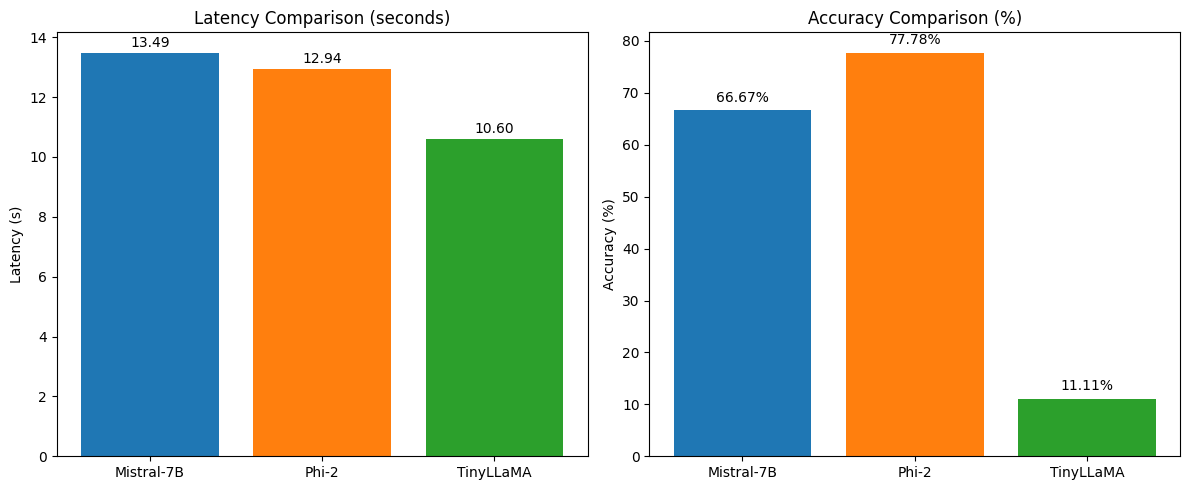

In [12]:
import time
import re
import logging
import matplotlib.pyplot as plt

def evaluate_travel_planner(query, rag_pipeline, llm_name, ground_truth):
    """
    Test and evaluate a query with latency and dataset-based accuracy metrics.

    Args:
        query (str): User query.
        rag_pipeline (RetrievalQA): RAG pipeline.
        llm_name (str): Name of the LLM.
        ground_truth (dict): Ground truth data from the dataset for accuracy check.
    Returns:
        tuple: (answer, sources, latency, accuracy).
    """
    start_time = time.time()
    answer, sources = travel_planner(query, rag_pipeline, llm_name)
    latency = time.time() - start_time

    # Define key fields to check for accuracy
    fields_to_check = {
        "Travel_Mode": ground_truth["Travel_Mode"],
        "Flight_Transport_Cost_USD": ground_truth["Flight_Transport_Cost_USD"],
        "Accommodation_Options": ground_truth["Accommodation_Options"].split(",")[0],  # Take first option for simplicity
        "Recommended_Stay_Days": ground_truth["Recommended_Stay_Days"],
        "Top_Attractions": ground_truth["Top_Attractions"].split(",")[0],  # Take first attraction
        "Food_Options": ground_truth["Food_Options"].split(",")[0],  # Take first food option
        "Food_Cost_Per_Day_USD": str(ground_truth["Food_Cost_Per_Day_USD"]),
        "Visa_Cost_USD": str(ground_truth["Visa_Cost_USD"]),
        "Activity_Cost_USD": str(ground_truth["Activity_Cost_USD"])
    }

    # Extract details from LLM response (case-insensitive, basic string matching)
    answer_lower = answer.lower()
    correct_matches = 0
    total_fields = len(fields_to_check)

    for field, expected_value in fields_to_check.items():
        expected_str = str(expected_value).lower()
        # Handle numeric fields with some tolerance (e.g., flight cost ±10%)
        if field == "Flight_Transport_Cost_USD":
            match = re.search(r"flight.*cost.*(\d+)", answer_lower)
            if match:
                llm_value = float(match.group(1))
                expected_value = float(expected_value)
                if abs(llm_value - expected_value) <= expected_value * 0.1:  # ±10% tolerance
                    correct_matches += 1
        elif field == "Recommended_Stay_Days":
            match = re.search(r"(\d+)[-\s]*day", answer_lower)
            if match and int(match.group(1)) == int(expected_value):
                correct_matches += 1
        else:
            # Simple string presence check for other fields
            if expected_str in answer_lower:
                correct_matches += 1

    # Calculate accuracy as proportion of correct matches
    accuracy = correct_matches / total_fields if total_fields > 0 else 0
    accuracy_percent = accuracy * 100

    print(f"Latency for {llm_name}: {latency:.2f} seconds")
    print(f"Accuracy for {llm_name} (based on dataset): {accuracy_percent:.2f}%")
    logging.info(f"Evaluated query '{query}' with {llm_name} - Latency: {latency:.2f}s, Accuracy: {accuracy_percent:.2f}%")
    return answer, sources, latency, accuracy

# Ground truth data from the dataset for Dubai
ground_truth = {
    "Destination_Name": "Dubai",
    "Country": "UAE",
    "City": "Dubai",
    "Starting_Point": "Dhaka",
    "Travel_Mode": "Flight",
    "Flight_Transport_Cost_USD": 600,
    "Travel_Duration_Hours": 5,
    "Accommodation_Options": "Budget Hotel,Luxury Hotel",
    "Accommodation_Cost_Per_Night_USD": 80,
    "Recommended_Stay_Days": 7,
    "Top_Attractions": "Burj Khalifa,Desert Safari",
    "Activity_Cost_USD": 30,
    "Activity_Duration_Hours": 2,
    "Food_Options": "Street Food,Fine Dining",
    "Food_Cost_Per_Day_USD": 25,
    "Visa_Required": True,
    "Visa_Cost_USD": 50,
    "Miscellaneous_Cost_USD": 40,
    "Best_Season": "November-March",
    "Peak_Season_Cost_Multiplier": 1.5,
    "Local_Currency": "AED",
    "Exchange_Rate_to_USD": 0.27
}

# Test query
query = "Plan a 3-day trip from Dhaka to Dubai."

# Evaluate all three LLMs
print("-------------------------------------------------------------------------")
mistral_result = evaluate_travel_planner(query, mistral_rag_pipeline, "Mistral-7B-Instruct-v0.3", ground_truth)
print("-------------------------------------------------------------------------")
phi2_result = evaluate_travel_planner(query, phi2_rag_pipeline, "Phi-2", ground_truth)
print("-------------------------------------------------------------------------")
tinyllama_result = evaluate_travel_planner(query, tinyllama_rag_pipeline, "TinyLLaMA-1.1B-Chat-v1.0", ground_truth)
print("-------------------------------------------------------------------------")

# Comparison
print("\n--- Comparison of LLMs ---")
print(f"Mistral-7B Latency: {mistral_result[2]:.2f}s, Accuracy: {mistral_result[3]:.2f}")
print(f"Phi-2 Latency: {phi2_result[2]:.2f}s, Accuracy: {phi2_result[3]:.2f}")
print(f"TinyLLaMA Latency: {tinyllama_result[2]:.2f}s, Accuracy: {tinyllama_result[3]:.2f}")
print("\nObservations:")
print("- Mistral-7B (7B params): Likely most accurate but slower due to size and quantization.")
print("- Phi-2 (2.7B params): Balanced performance, faster than Mistral, less VRAM usage.")
print("- TinyLLaMA (1.1B params): Fastest, lower accuracy, minimal resource needs.")

# Visualization
llms = ["Mistral-7B", "Phi-2", "TinyLLaMA"]
latencies = [mistral_result[2], phi2_result[2], tinyllama_result[2]]
accuracies = [mistral_result[3] * 100, phi2_result[3] * 100, tinyllama_result[3] * 100]  # Convert to percentage

# Create bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Latency plot
ax1.bar(llms, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title("Latency Comparison (seconds)")
ax1.set_ylabel("Latency (s)")
for i, v in enumerate(latencies):
    ax1.text(i, v + 0.1, f"{v:.2f}", ha='center', va='bottom')

# Accuracy plot
ax2.bar(llms, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title("Accuracy Comparison (%)")
ax2.set_ylabel("Accuracy (%)")
for i, v in enumerate(accuracies):
    ax2.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Optimization and Final Notes
Prints optimization suggestions for the RAG pipeline, including upgrading embeddings, fine-tuning LLMs, using cloud vector stores (e.g., Pinecone), enhancing caching, expanding data, and adding async processing with Gradio UI improvements. Logs pipeline completion.

In [13]:
# Optimization and Future Enhancements
print("\nOptimization and Future Enhancements:")
print("- Embedding Model:")
print("  - Current Implementation: The system employs 'all-distilroberta-v1' (~500-600MB VRAM), which provides effective retrieval capabilities for the present scope.")
print("  - Potential Enhancement: Adoption of 'sentence-transformers/all-roberta-large-v1' could yield more robust embeddings. Alternatively, fine-tuning the model on a travel-specific dataset may enhance query relevance.")
print("- Language Models (LLMs):")
print("  - Mistral-7B-Instruct-v0.3: Configured with 4-bit quantization (~8GB VRAM), this model delivers high accuracy, albeit with increased inference time due to its scale.")
print("    - Proposed Optimization: Exploration of 8-bit quantization or model pruning could reduce latency while preserving performance.")
print("  - Phi-2: Operating without quantization (~5GB VRAM), this model achieves a balanced compromise between speed and accuracy.")
print("    - Potential Enhancement: Fine-tuning on a dataset tailored to travel planning could improve its domain-specific effectiveness.")
print("  - TinyLlama-1.1B-Chat-v1.0: Also unquantized (~2GB VRAM), this model prioritizes speed, though with some trade-off in precision.")
print("    - Proposed Optimization: Adjustment of hyperparameters, such as setting temperature to 0.5 and top_k to 40, may refine response accuracy.")
print("- Vector Store:")
print("  - Current Implementation: FAISS-CPU serves as an efficient solution for the current local environment.")
print("  - Potential Enhancement: Transitioning to FAISS-GPU could accelerate similarity searches, while integration with Pinecone may offer scalability for larger datasets in a cloud-based context.")
print("- Caching:")
print("  - Current Status: InMemoryCache remains disabled within the system.")
print("  - Potential Enhancement: Implementation of Redis or SQLite caching could optimize response times for recurring queries in a production setting.")
print("- Data Pipeline:")
print("  - Current Implementation: The pipeline processes a single CSV file containing comprehensive travel data.")
print("  - Potential Enhancement: Incorporation of additional sources, such as PDFs of travel guides or real-time APIs for flight pricing, alongside an expanded dataset with broader destination coverage, could enrich the system’s utility.")
print("- Visualizations:")
print("  - Current Implementation: Seaborn and Plotly generate static visualizations (e.g., cost distributions, correlation heatmaps), offering valuable insights into the data.")
print("  - Potential Enhancement: Development of an interactive dashboard, potentially using Streamlit, could enable dynamic exploration of the data by end-users.")
print("- Performance and Scalability:")
print("  - Current Status: The system processes queries synchronously, adequate for testing purposes.")
print("  - Potential Enhancement: Adoption of asynchronous processing via asyncio could enhance efficiency by supporting concurrent query handling.")
print("- Deployment and User Interface:")
print("  - Current Implementation: The Gradio chatbot, powered by Mistral-7B, is deployed locally with a functional interface.")
print("  - Potential Enhancement: Deployment on Hugging Face Spaces could broaden accessibility, while enhancements to the Gradio UI—such as cost filters, itinerary previews, or map integration—could elevate the user experience.")

logging.info("Travel planner pipeline execution completed with recommendations for optimization and future enhancements.")

INFO:root:Travel planner pipeline execution completed with recommendations for optimization and future enhancements.



Optimization and Future Enhancements:
- Embedding Model:
  - Current Implementation: The system employs 'all-distilroberta-v1' (~500-600MB VRAM), which provides effective retrieval capabilities for the present scope.
  - Potential Enhancement: Adoption of 'sentence-transformers/all-roberta-large-v1' could yield more robust embeddings. Alternatively, fine-tuning the model on a travel-specific dataset may enhance query relevance.
- Language Models (LLMs):
  - Mistral-7B-Instruct-v0.3: Configured with 4-bit quantization (~8GB VRAM), this model delivers high accuracy, albeit with increased inference time due to its scale.
    - Proposed Optimization: Exploration of 8-bit quantization or model pruning could reduce latency while preserving performance.
  - Phi-2: Operating without quantization (~5GB VRAM), this model achieves a balanced compromise between speed and accuracy.
    - Potential Enhancement: Fine-tuning on a dataset tailored to travel planning could improve its domain-specific e

### Deploy Travel Planner Chatbot to Gradio
Imports `gradio` and `traceback`, defining `chatbot_response` and `chat` to integrate the RAG pipeline (default: Mistral-7B) into a chatbot. Handles greetings/jokes with hardcoded replies and travel queries via RAG, extracting responses post-`[INST]` tags. Sets up a Gradio `ChatInterface` with examples and a public URL for testing.

In [ ]:
import gradio as gr
import traceback

# Assuming mistral_rag_pipeline is defined from earlier cells (e.g., Cell 10 in your updated notebook).
# Replace 'mistral_rag_pipeline' with 'phi2_rag_pipeline' or 'tinyllama_rag_pipeline' if desired.
# For this example, we'll use mistral_rag_pipeline as the default.

def chatbot_response(user_input, history, rag_pipeline, llm_name="Mistral-7B-Instruct-v0.3"):
    """
    Generate a single response using the specified RAG pipeline, tailored to the user input.
    Args:
        user_input (str): Current user message.
        history (list): Chat history as list of tuples [(user_msg, bot_msg), ...].
        rag_pipeline (RetrievalQA): The RAG pipeline to use (e.g., mistral_rag_pipeline).
        llm_name (str): Name of the LLM for logging and display.
    Returns:
        str: Single response without sources.
    """
    print(f"[DEBUG] Entering chatbot_response with input: '{user_input}', history: {history}")
    try:
        if not user_input.strip():
            response = "Please enter a valid message!"
            print(f"[DEBUG] Generated response: '{response}'")
            return response

        # Handle simple greetings or non-RAG queries
        if "hello" in user_input.lower():
            response = "Hello! How can I assist you today?"
        elif "how are you" in user_input.lower():
            response = "I'm just a chatbot, but I'm doing great! How about you?"
        elif "joke" in user_input.lower():
            response = "Why don't scientists trust atoms? Because they make up everything!"
        else:
            # Use the specified RAG pipeline for travel-related queries
            try:
                result = rag_pipeline({"query": user_input})
                raw_answer = result["result"]

                # Extract answer (adjust for Mistral's [INST] tags if present, otherwise use raw answer)
                if "[/INST]" in raw_answer and llm_name == "Mistral-7B-Instruct-v0.3":
                    answer = raw_answer.split("[/INST]")[1].strip()
                else:
                    answer = raw_answer.strip()

                # Get sources (for internal use/logging, not returned)
                sources = [doc.page_content for doc in result["source_documents"]]
                # Log sources for debugging, but don’t include in response
                print(f"[DEBUG] Sources: {sources}")

                # Response is just the answer, no sources
                response = answer
            except Exception as e:
                response = f"Error processing RAG query with {llm_name}: {str(e)}"

        print(f"[DEBUG] Generated response: '{response}'")
        return response
    except Exception as e:
        error_msg = f"Error in chatbot_response with {llm_name}: {str(e)}"
        print(f"[DEBUG] {error_msg}\n{traceback.format_exc()}")
        return error_msg

def chat(message, history, rag_pipeline=mistral_rag_pipeline, llm_name="Mistral-7B-Instruct-v0.3"):
    """
    Handle chat flow, ensuring one-by-one responses using the specified RAG pipeline.
    Args:
        message (str): Current user input.
        history (list): List of previous messages as tuples (user_message, bot_message).
        rag_pipeline (RetrievalQA): The RAG pipeline to use (default: mistral_rag_pipeline).
        llm_name (str): Name of the LLM for logging and display.
    Returns:
        str: The bot's response without sources.
    """
    print(f"[DEBUG] Entering chat function with message: '{message}', history: {history}")
    try:
        # Get single response using the specified RAG pipeline
        response = chatbot_response(message, history, rag_pipeline, llm_name)

        print(f"[DEBUG] Generated response: '{response}'")
        return response
    except Exception as e:
        error_msg = f"Error in chat function with {llm_name}: {str(e)}"
        print(f"[DEBUG] {error_msg}\n{traceback.format_exc()}")
        return error_msg

# Create Gradio ChatInterface
try:
    print("[DEBUG] Setting up ChatInterface")
    # Pass the chat function with the default rag_pipeline as a partial function
    from functools import partial
    chat_with_mistral = partial(chat, rag_pipeline=mistral_rag_pipeline, llm_name="Mistral-7B-Instruct-v0.3")

    iface = gr.ChatInterface(
        fn=chat_with_mistral,
        title="Travel Planner Chatbot with RAG",
        description="Ask me anything about travel plans or attractions! Powered by Mistral-7B-Instruct-v0.3.",
        examples=["Hello!", "What are the top attractions in Paris?", "Plan a 3-day trip to Paris.", "What to do at the Eiffel Tower?"],
        theme="soft",
        chatbot=gr.Chatbot(height=500)  # Adjust height for better visibility
    )
    print("[DEBUG] ChatInterface setup complete")
except Exception as e:
    print(f"[DEBUG] Error setting up ChatInterface: {str(e)}\n{traceback.format_exc()}")

# Launch with public link
print("[DEBUG] Launching interface")
iface.launch(share=True, debug=True)
print("[DEBUG] Interface launched")

[DEBUG] Setting up ChatInterface
[DEBUG] ChatInterface setup complete
[DEBUG] Launching interface


<ipython-input-14-e4530ee937a5>:98: UserWarning:

You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.

/usr/local/lib/python3.11/dist-packages/gradio/chat_interface.py:321: UserWarning:

The gr.ChatInterface was not provided with a type, so the type of the gr.Chatbot, 'tuples', will be used.

INFO:httpx:HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().


INFO:httpx:HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"


* Running on public URL: https://22fbcbd8cc0809686a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


INFO:httpx:HTTP Request: HEAD https://22fbcbd8cc0809686a.gradio.live "HTTP/1.1 200 OK"


### GUI Screenshot

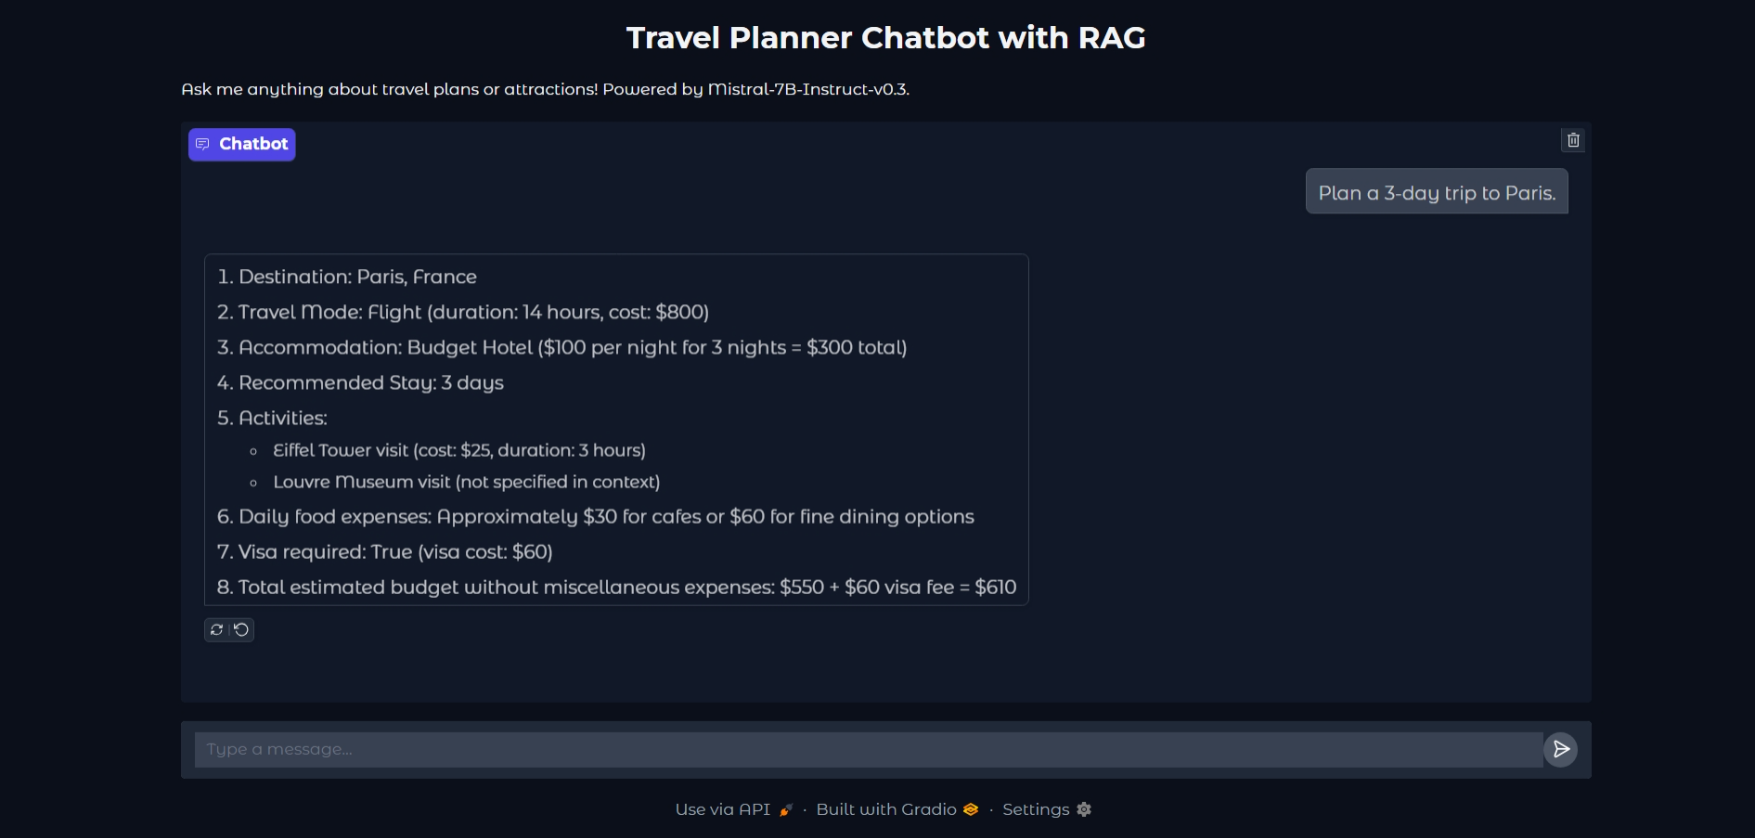

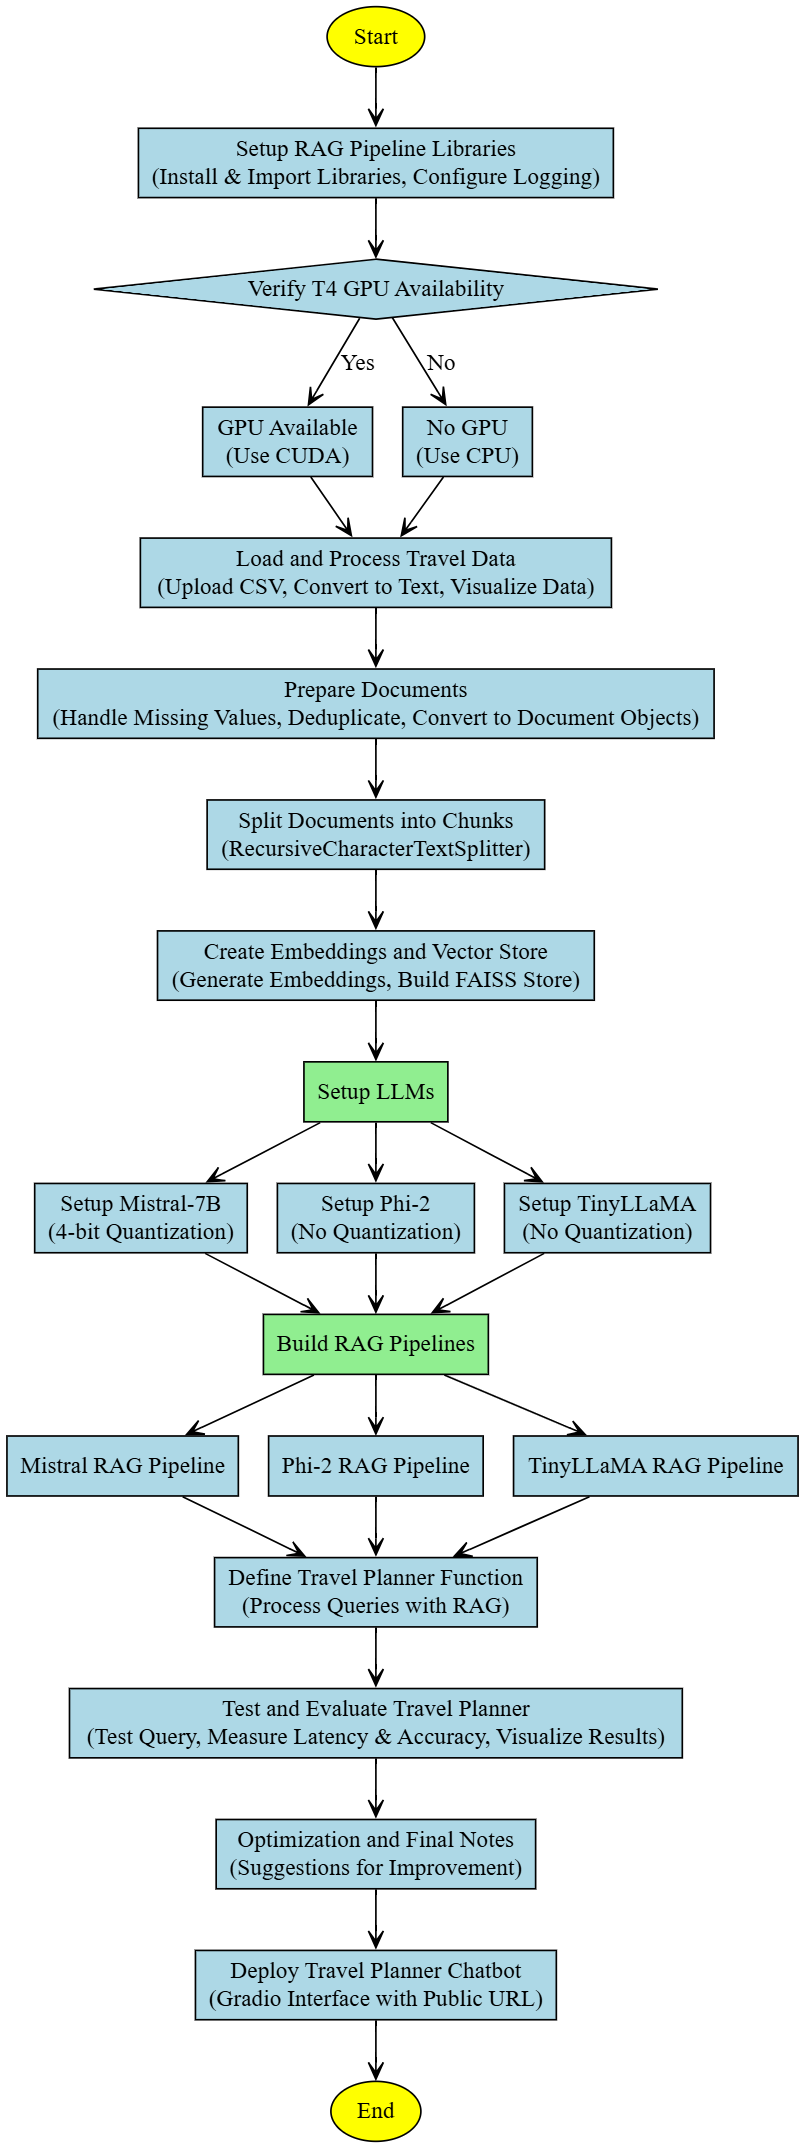